# News Source Classification — Preprocessing

CIS 5190 final project, Track B. Loads the scraped headline CSV, derives source labels from URLs, cleans the text, audits for leakage, and writes train/val splits.

**Inputs:** `data/url_dataset_headlines.csv`  
**Outputs:** `data/headlines_clean.csv`, `data/train.csv`, `data/val.csv`

Decisions worth flagging:
- We keep raw casing and punctuation in the cleaned CSV. Lowercasing / stopword removal / stemming belong in modeling, so we can ablate them.
- The label `source` comes from the URL domain (fox vs nbc), since the hidden test set won't ship a label column.
- We do a stratified 80/20 split here so every model trains on the same partition.

In [1]:
import re
import unicodedata
from urllib.parse import urlparse

import pandas as pd
from sklearn.model_selection import train_test_split

RAW_PATH = "data/url_dataset_headlines.csv"
CLEAN_PATH = "data/headlines_clean.csv"
TRAIN_PATH = "data/train.csv"
VAL_PATH = "data/val.csv"
RANDOM_STATE = 42

## 1. Load and inspect

In [2]:
df = pd.read_csv(RAW_PATH)
print("shape:", df.shape)
print("columns:", list(df.columns))
df.head()

shape: (3805, 2)
columns: ['url', 'headline']


,url,headline
0,https://www.foxnews.com/lifestyle/jack-carrs-e...,Jack Carr recalls Gen. Eisenhower's D Day memo...
1,https://www.foxnews.com/entertainment/bruce-wi...,"Bruce Willis, Demi Moore avoided doing one thi..."
2,https://www.foxnews.com/politics/blinken-meets...,"Blinken meets Qatar PM, says Israeli actions a..."
3,https://www.foxnews.com/entertainment/emily-bl...,Emily Blunt says her ‘toes curl’ when people t...
4,https://www.foxnews.com/media/the-view-co-host...,"'The View' co host, CNN commentator Ana Navarr..."


In [3]:
print("nulls:")
print(df.isna().sum())
print("\nduplicate urls:", df['url'].duplicated().sum())
print("duplicate headlines:", df['headline'].duplicated().sum())

nulls:
url         0
headline    6
dtype: int64

duplicate urls: 0
duplicate headlines: 7


## 2. Drop missing rows and duplicates

In [4]:
before = len(df)
df = df.dropna(subset=["url", "headline"])
df = df.drop_duplicates(subset=["url"])
df = df.drop_duplicates(subset=["headline"])
print(f"dropped {before - len(df)} rows; {len(df)} remain")

dropped 8 rows; 3797 remain


## 3. Normalize unicode and whitespace

The raw text mixes curly quotes (`'`, `"`) with straight ones — without normalization, a tokenizer sees `don't` and `don't` as different tokens. We also collapse repeated whitespace and strip.

In [5]:
def clean_headline(text: str) -> str:
    text = unicodedata.normalize("NFKC", str(text))
    text = text.replace("\u2018", "'").replace("\u2019", "'")
    text = text.replace("\u201c", '"').replace("\u201d", '"')
    text = text.replace("\u2013", "-").replace("\u2014", "-")
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["headline"] = df["headline"].map(clean_headline)
df = df[df["headline"].str.len() >= 10].reset_index(drop=True)
df.head()

,url,headline
0,https://www.foxnews.com/lifestyle/jack-carrs-e...,Jack Carr recalls Gen. Eisenhower's D Day memo...
1,https://www.foxnews.com/entertainment/bruce-wi...,"Bruce Willis, Demi Moore avoided doing one thi..."
2,https://www.foxnews.com/politics/blinken-meets...,"Blinken meets Qatar PM, says Israeli actions a..."
3,https://www.foxnews.com/entertainment/emily-bl...,Emily Blunt says her 'toes curl' when people t...
4,https://www.foxnews.com/media/the-view-co-host...,"'The View' co host, CNN commentator Ana Navarr..."


## 4. Derive `source` label and `category` from the URL

`source` is the prediction target (fox vs nbc). `category` is the first path segment (e.g. `politics`, `sports`); not used for the classifier, but useful for stratified analysis.

In [6]:
def parse_url(url: str) -> pd.Series:
    p = urlparse(url)
    host = p.netloc.lower()
    if host.startswith("www."):
        host = host[4:]
    if "foxnews" in host:
        source = "fox"
    elif "nbcnews" in host:
        source = "nbc"
    else:
        source = "other"
    parts = [s for s in p.path.split("/") if s]
    category = parts[0] if parts else ""
    return pd.Series({"source": source, "category": category})

df[["source", "category"]] = df["url"].apply(parse_url)
df = df[df["source"] != "other"].reset_index(drop=True)
df["source"].value_counts()

source
fox    1998
nbc    1799
Name: count, dtype: int64

In [7]:
df["category"].value_counts().head(15)

category
politics         1294
news              623
media             387
select            269
lifestyle         203
us                200
entertainment     165
world             110
sports            100
health             99
tech               80
travel             41
opinion            39
food-drink         35
science            28
Name: count, dtype: int64

## 5. Leakage audit

If a headline literally contains `Fox`, `NBC`, `MSNBC`, etc., a model can shortcut on that token instead of learning style. The hidden test set probably won't have this pattern, so we want to know how many rows are affected.

In [8]:
leak_pat = re.compile(r"\b(fox news|fox|nbc news|nbc|msnbc|today show|meet the press)\b", re.IGNORECASE)
df["has_outlet_mention"] = df["headline"].str.contains(leak_pat)
leak_breakdown = df.groupby("source")["has_outlet_mention"].agg(["sum", "count", "mean"])
leak_breakdown

/var/folders/x9/d2smpv6s34j1xwzzfgjtwwtw0000gn/T/ipykernel_83599/1746388748.py:2: UserWarning: This pattern is interpreted as a regular expression, and has match groups. To actually get the groups, use str.extract.
  df["has_outlet_mention"] = df["headline"].str.contains(leak_pat)


,sum,count,mean
source,,,
fox,23,1998,0.011512
nbc,3,1799,0.001668


In [9]:
df[df["has_outlet_mention"]].head(10)[["source", "headline"]]

,source,headline
98,fox,"Channel dominates CNN, MSNBC during historic c..."
260,fox,You'll laugh at who MSNBC brought to whine abo...
278,fox,Bill Maher shocked by MSNBC's softball Kamala ...
352,fox,"NYT, MSNBC, PBS journalists pressed on how the..."
353,fox,Rachel Maddow defends MSNBC's refusal to air T...
484,fox,Reporter on MSNBC says migrants 'not angry at ...
499,fox,Rittenhouse judge bans MSNBC from courtroom af...
581,fox,MSNBC host rages after seeing polls showing Tr...
605,fox,"NYT, MSNBC's Mara Gay: 'Disturbing' to see 'do..."
857,fox,"Democratic National Convention features CNN, M..."


Decision: leave these rows in for now (removing them throws away real headlines), but the modeling notebook should ablate with/without these tokens to measure how much accuracy comes from the shortcut.

## 6. Length distribution

If one outlet writes systematically longer headlines, that's a real (but stylistic) signal. Worth knowing.

In [10]:
df["char_len"] = df["headline"].str.len()
df["word_len"] = df["headline"].str.split().str.len()
df.groupby("source")[["char_len", "word_len"]].agg(["mean", "median", "std"])

char_len                     word_len                 
             mean median        std       mean median       std
source                                                         
fox     88.452452   90.0  15.322881  13.915916   14.0  2.609819
nbc     76.827682   77.0  16.942003  12.612563   12.0  3.005275

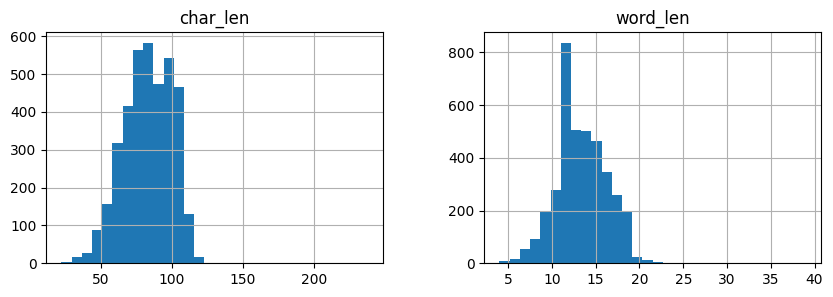

In [11]:
df[["char_len", "word_len"]].hist(bins=30, figsize=(10, 3));

## 7. Stratified 80/20 train/val split

Stratify on `source` so the class balance is preserved in both partitions.

In [12]:
final_cols = ["url", "source", "category", "headline"]
df_final = df[final_cols].copy()

train_df, val_df = train_test_split(
    df_final,
    test_size=0.2,
    stratify=df_final["source"],
    random_state=RANDOM_STATE,
)
print("train:", train_df.shape, " val:", val_df.shape)
print("\ntrain class balance:")
print(train_df["source"].value_counts(normalize=True))
print("\nval class balance:")
print(val_df["source"].value_counts(normalize=True))

train: (3037, 4)  val: (760, 4)

train class balance:
source
fox    0.526177
nbc    0.473823
Name: proportion, dtype: float64

val class balance:
source
fox    0.526316
nbc    0.473684
Name: proportion, dtype: float64


## 8. Save

In [13]:
df_final.to_csv(CLEAN_PATH, index=False)
train_df.to_csv(TRAIN_PATH, index=False)
val_df.to_csv(VAL_PATH, index=False)
print(f"wrote {len(df_final)} rows to {CLEAN_PATH}")
print(f"wrote {len(train_df)} rows to {TRAIN_PATH}")
print(f"wrote {len(val_df)} rows to {VAL_PATH}")

wrote 3797 rows to data/headlines_clean.csv
wrote 3037 rows to data/train.csv
wrote 760 rows to data/val.csv
